# Loop Generator Waveform


SIMPLE LOOP GENERATOR WAVEFORM SIMULATOR
From Lecture Notes: ch-26-Dc-generators.pdf (Fig. 26.2 – 26.7)
Maximum EMF (Em)          = 10.0 V
Frequency of rotation     = 1.0 Hz
Coil EMF                  = Em × sin(θ)     → ALTERNATING
After Commutator          = Em × |sin(θ)|   → UNIDIRECTIONAL but PULSATING


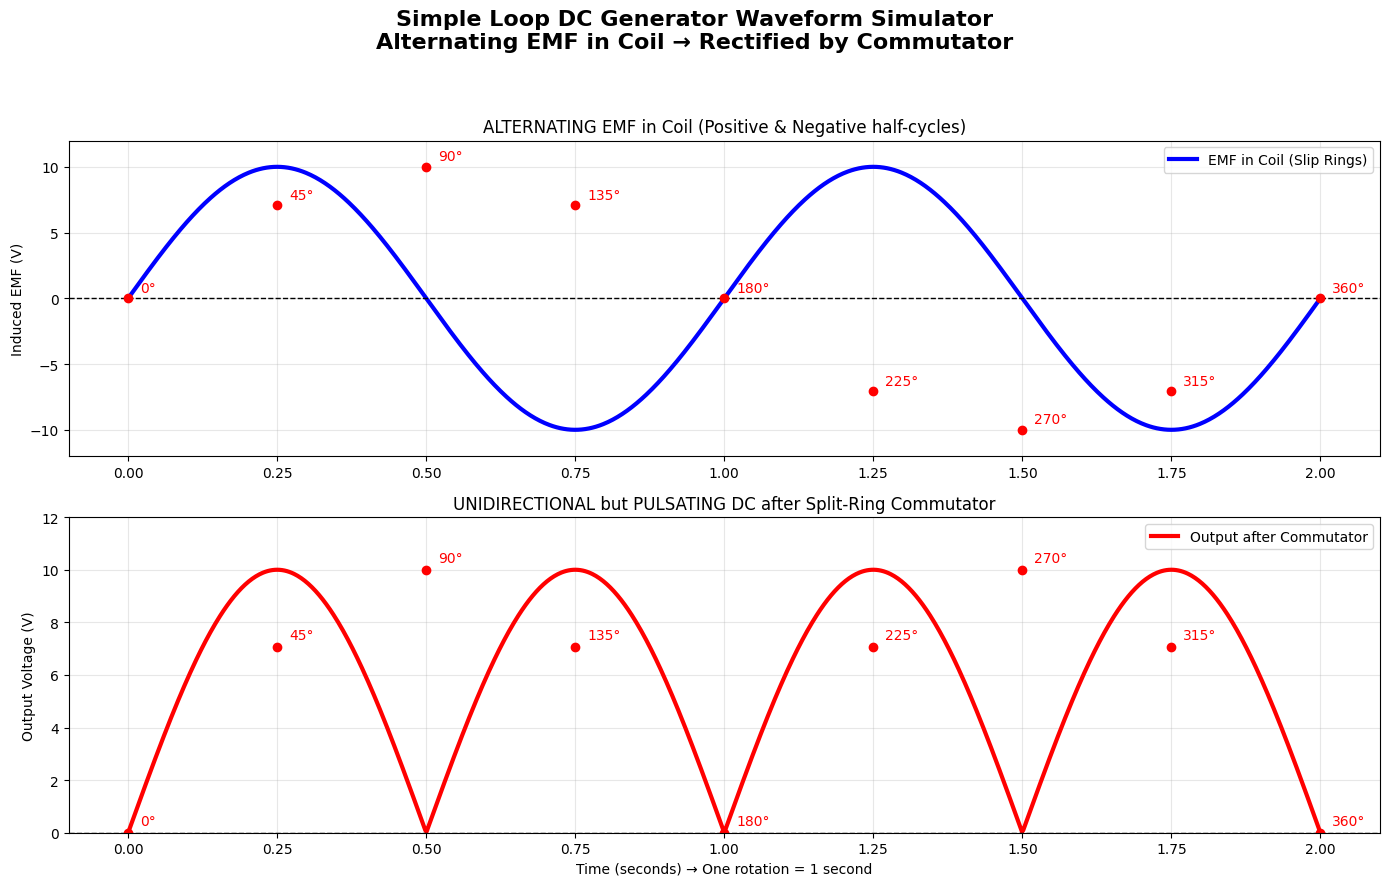

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ====================== PARAMETERS ======================
Em = 10.0                  # Maximum induced EMF in the coil (V)
f = 1.0                    # Frequency of rotation (Hz) -> 1 rotation per second for clear view
omega = 2 * np.pi * f      # Angular frequency (rad/s)

# Time array - two full rotations (0 to 720 degree) for clear view of two cycles
t = np.linspace(0, 2, 1000)          # 2 seconds -> two full rotations
theta = omega * t                    # Theta in radians (0 to 4 pi)

# ====================== CALCULATIONS ======================
# 1. Alternating EMF induced in the coil (slip-ring case)
e_coil = Em * np.sin(theta)          # Sinusoidal AC waveform

# 2. Rectified output after commutator (split-ring)
e_commutator = Em * np.abs(np.sin(theta))

# Key positions (like Fig. 26.2 in your notes)
positions_deg = [0, 45, 90, 135, 180, 225, 270, 315, 360]
positions_rad = np.deg2rad(positions_deg)
e_at_positions = Em * np.sin(positions_rad)

print("\n" + "="*70)
print("SIMPLE LOOP GENERATOR WAVEFORM SIMULATOR")
print("From Lecture Notes: ch-26-Dc-generators.pdf (Fig. 26.2 – 26.7)")
print("="*70)
print(f"Maximum EMF (Em) = {Em} V")
print(f"Frequency of rotation = {f} Hz")
print(f"Coil EMF      = Em × sin(θ)  -> ALTERNATING")
print(f"After Commutator = Em × |sin(θ)|  -> UNIDIRECTIONAL but PULSATING")
print("="*70)

fig, axs = plt.subplots(2, 1, figsize=(14, 9))
fig.suptitle('Simple Loop DC Generator Waveform Simulator\n'
             'Alternating EMF in Coil → Rectified by Commutator',
             fontsize=16, fontweight='bold')

axs[0].plot(t, e_coil, 'b-', linewidth=3, label='EMF in Coil (Slip Rings)')
axs[0].axhline(0, color='black', linestyle='--', linewidth=1)
axs[0].set_ylabel('Induced EMF (V)')
axs[0].set_title('ALTERNATING EMF in Coil (Positive & Negative half-cycles)')
axs[0].grid(True, alpha=0.3)

# Mark key positions (0°, 90°, 180°, 270°, 360°)
for i, pos in enumerate(positions_deg):
    t_pos = pos / 360.0 * 2   # Time corresponding to angle
    e_pos = e_at_positions[i]
    axs[0].plot(t_pos, e_pos, 'ro', markersize=6)
    axs[0].text(t_pos + 0.02, e_pos + 0.5, f'{pos}°', fontsize=10, color='red')

axs[0].legend(loc='upper right')
axs[0].set_ylim(-Em*1.2, Em*1.2)

axs[1].plot(t, e_commutator, 'r-', linewidth=3, label='Output after Commutator')
axs[1].axhline(0, color='black', linestyle='--', linewidth=1)
axs[1].set_xlabel('Time (seconds) → One rotation = 1 second')
axs[1].set_ylabel('Output Voltage (V)')
axs[1].set_title('UNIDIRECTIONAL but PULSATING DC after Split-Ring Commutator')
axs[1].grid(True, alpha=0.3)

# Mark the same key positions on rectified waveform
for i, pos in enumerate(positions_deg):
    t_pos = pos / 360.0 * 2
    e_pos = Em * abs(np.sin(positions_rad[i]))
    axs[1].plot(t_pos, e_pos, 'ro', markersize=6)
    axs[1].text(t_pos + 0.02, e_pos + 0.3, f'{pos}°', fontsize=10, color='red')

axs[1].legend(loc='upper right')
axs[1].set_ylim(0, Em*1.2)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()